# FTIML Assignment 2: Fairness (10 points)

## Dataset: 2021 British Columnbia (Canada) Census data

The dataset represents the 2021 British Columbia (Canada) Census data. Each row describes the demographic and socioeconomic characteristics of an individual. The objective is to predict whether an individual's income exceeds 75K. These predictions will be used by a company that determines loan approvals based on your model's output. An individual's income may be influenced by their demographic and socioeconomic attributes. However, the company is legally prohibited from engaging in unfair treatment on the basis of "race, national or ethnic origin, colour, religion, age, sex, sexual orientation, gender identity or expression, marital status, family status, genetic characteristics, disability, or conviction for an offence for which a pardon has been granted or in respect of which a record suspension has been ordered", as outlined in the Canadian Human Rights Act. Your task is to analyze the fairness of your model's predictions and to apply techniques to improve the fairness of your models.

See for more information on the dataset "2021 Census Individuals PUMF User Guide.pdf". You are not required to read the entire document. 

Hint: Unavailable data is often encoded by 88888888 or 99999999.

## Deliverable:

A **.zip file** containing two elements: 
1. The **Jupyter notebook** you used for your analysis of Tasks a - d below (in ipynb).  
2. A **report of max. 4 pages** with the complete answers to the questions below (in pdf). 

**DEADLINE: Monday May 11, 2026 at 23:59.**

Note: All information in 2. needs to be contained in 1. (not necessarily vice versa).

Note: The grade for the assignment is primarily based on your presentation on May 12 and your report. The notebook serves as an add-on.


## Task a: Data Exploration
Before entering the analysis, spend some time to understand the data. 

* Which features do you expect to influence fairness?
* Define groups based on the sensitive feature(s) and visualize the data.
* Are there any inbalances? How might these affect your fairness analysis? 

Use graphs and/or tables, and write down your observations. 


## Task b: Explore Fairness
Take the outcomes of a black-box model (you may use the random forest model fitted below or for example a XGBoost model, neural network, ...) and an interpretable model of your choice and analyze their fairness across different protected groups.

*   Choose and report three group fairness metrics that are useful for the given context and report them.
*   Do you find evidence for biases in the models? Which group(s) appear to be at a disadvantage?
*   Are there any differences in fairness metrics between the black-box and interpretable models?

Use visualizations to support your analysis. Summarize the results in text. 


## Task c: Individual Fairness
Try to improve the fairness of your models using two individual fairness techniques.

Refer to the lecture slides and the notebook from the fairness tutorial for guidance on what is expected here.

Clearly state the techniques you are using and elaborate on their effects on the fairness of the models.


## Task d: Group Fairness
Try to improve the fairness metrics of your models using two group fairness techniques.

Explain why you choose the techniques you are using and elaborate on their effects on the fairness of the models.


# Preparations

## Install and load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

## Load and preprocess data
**Do not change this part**

In [2]:

data = pd.read_csv('data/data_donnees_2021_ind_BC.csv')
#print columns all column s
print(list(data.columns))

['PPSORT', 'ABOID', 'AGEGRP', 'AGEIMM', 'ATTSCH', 'BFNMEMB', 'BEDRM', 'CFSTAT', 'CHDBN', 'CIP2021', 'CIP2021_STEM_SUM', 'CMA', 'CONDO', 'COVID_ERB', 'COW', 'CQPPB', 'CfSize', 'ChldC', 'CitOth', 'Citizen', 'DIST', 'DPGRSUM', 'DTYPE', 'EFDecile', 'EFInc', 'EFInc_AT', 'EICBN', 'ETHDER', 'EfDIMBM_2018', 'EfSize', 'FOL', 'FPTWK', 'Gender', 'GENSTAT', 'GTRfs', 'HCORENEED_IND', 'HDGREE', 'HHSIZE', 'HHTYPE', 'HLMOSTEN', 'HLMOSTFR', 'HLMOSTNO', 'HLREGEN', 'HLREGFR', 'HLREGNO', 'IMMCAT5', 'IMMSTAT', 'JOBPERM', 'KOL', 'LFACT', 'LICO_BT', 'LICO_AT', 'LIPROGTYPE', 'LI_ELIG_OML_U18', 'LOCSTUD', 'LOC_ST_RES', 'LSTWRK', 'LWMOSTEN', 'LWMOSTFR', 'LWMOSTNO', 'LWREGEN', 'LWREGFR', 'LWREGNO', 'LoLIMA', 'LoLIMB', 'LOMBM_2018', 'MODE', 'MTNEn', 'MTNFr', 'MTNNO', 'MARSTH', 'Mob1', 'Mob5', 'NAICS', 'NOC21', 'NOS', 'OASGI', 'PKID25', 'PKID0_1', 'PKID15_24', 'PKID2_5', 'PKID6_14', 'PKIDS', 'POB', 'POBPAR1', 'POBPAR2', 'POWST', 'PR1', 'PR5', 'PRESMORTG', 'PRIHM', 'PWDUR', 'PWLEAVE', 'PWOCC', 'PWPR', 'REGIND', 'RE

In [3]:
# get features and target
AGEGRP = data['AGEGRP'] # this serves as an example, you can choose other sensitive attributes
X = pd.get_dummies(data.drop(columns=["75k"]))
y = data["75k"]

## Exploratory data analysis and feature engineering
Inspect the data and do some plots that help you understand the dataset here.

**Optional**: The dataset is already preprocessed. However, it might still pay off to invest some time in additional preprocessing here here (scaling, feature engineering, ...). This might improve model quality and help to rectify modeling errors.

**Note**: The data is imbalanced.

In [4]:
print(y.value_counts())

75k
0    44476
1    12014
Name: count, dtype: int64


/Users/lshyshova/git_tree/fair_ml/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



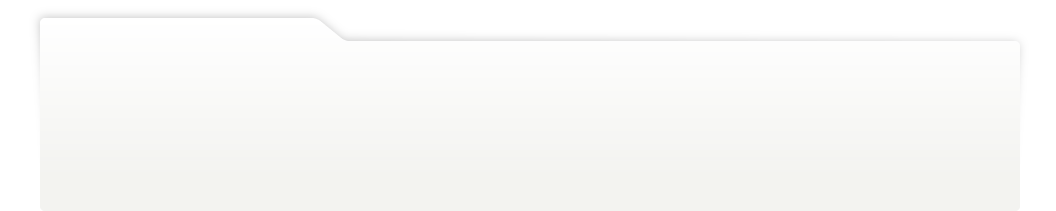
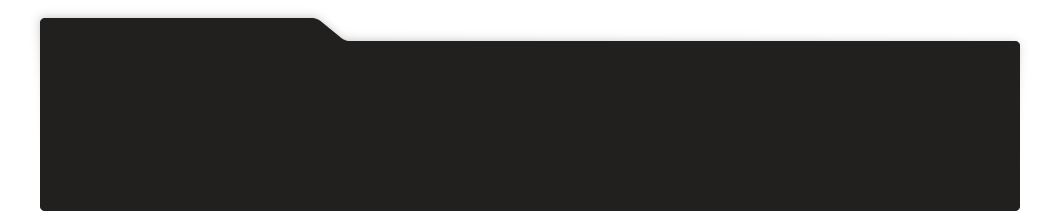
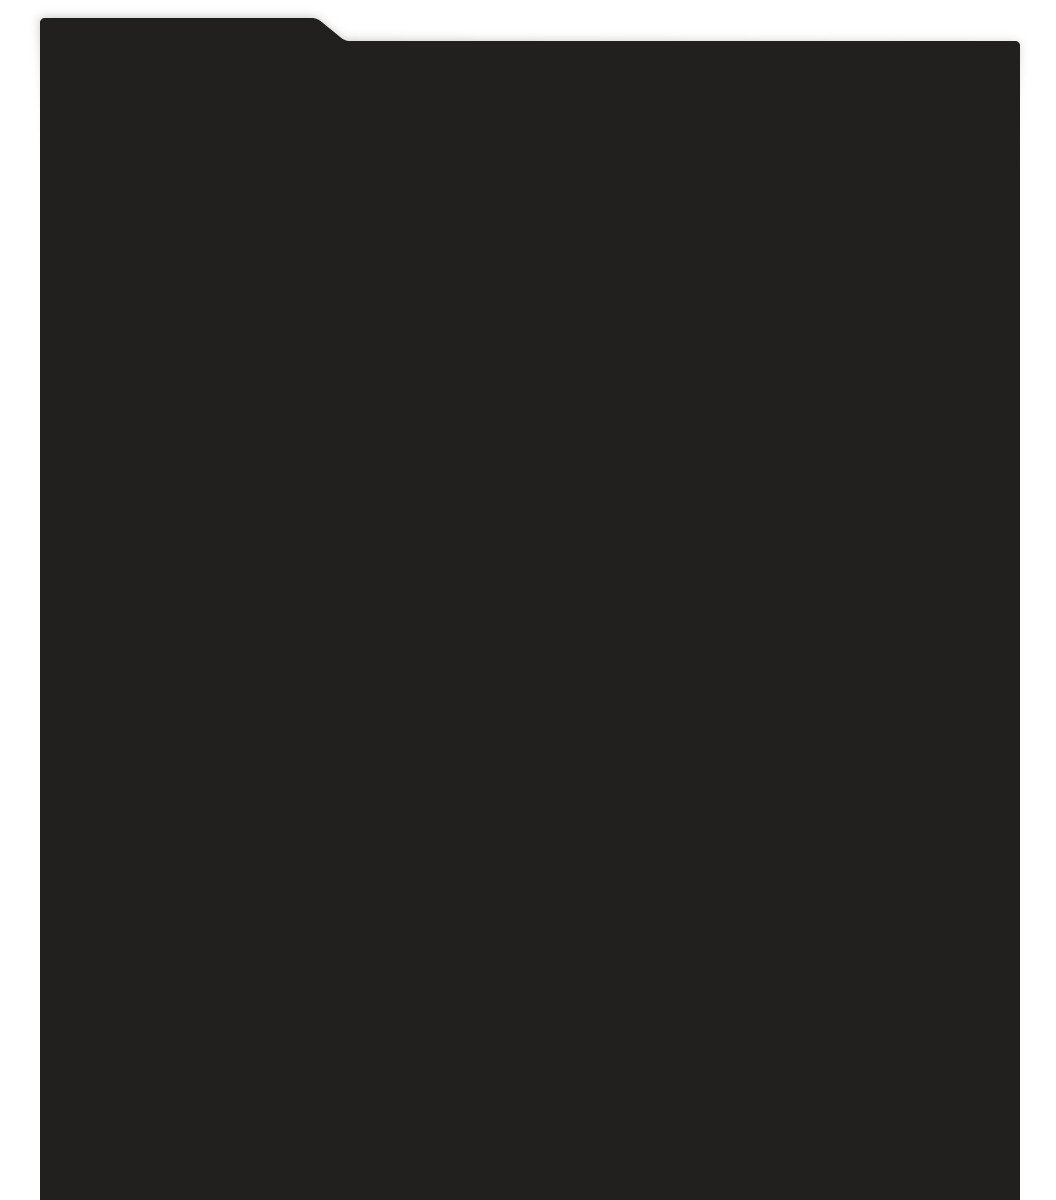
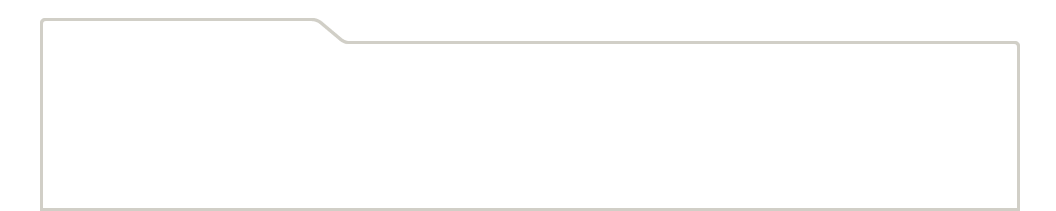
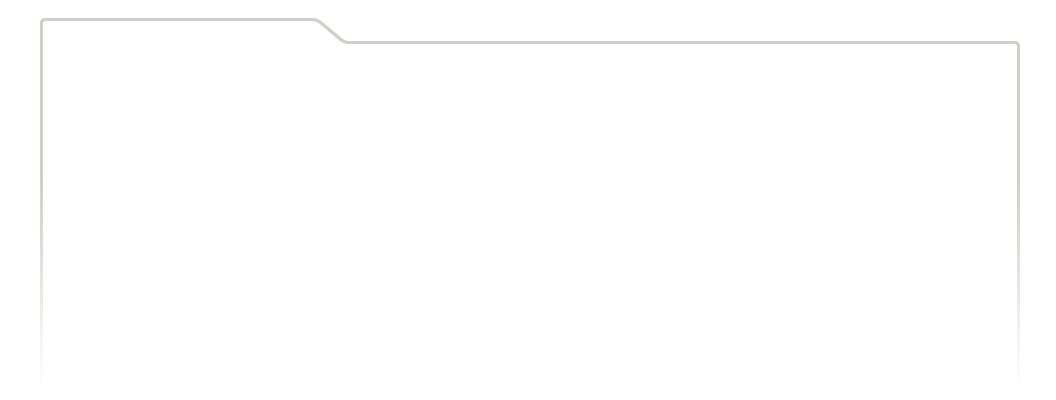
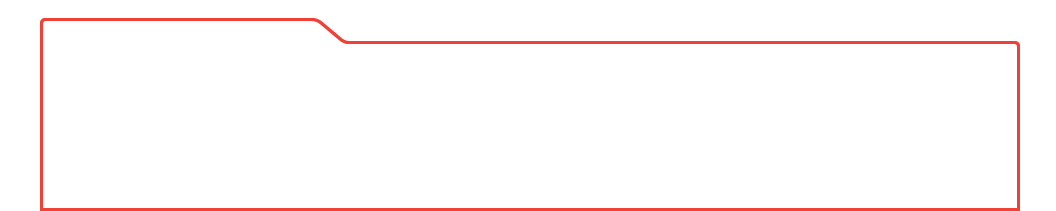
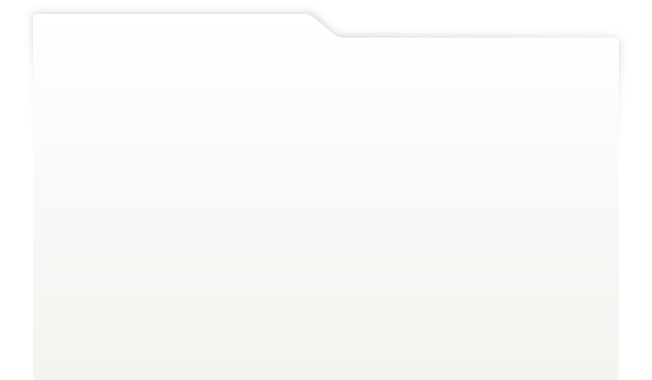
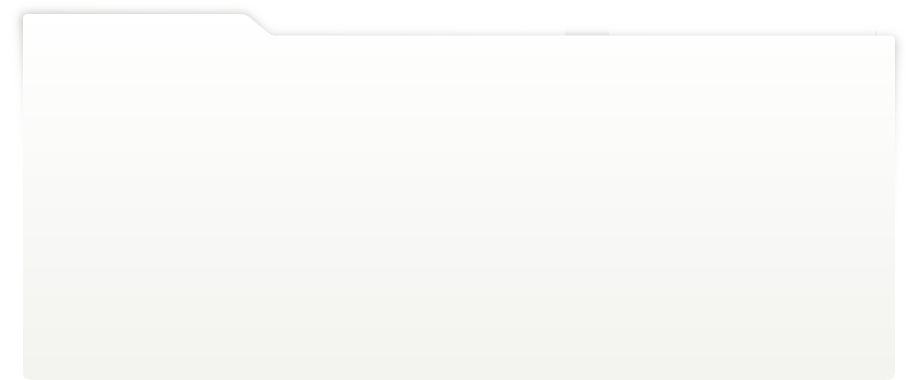
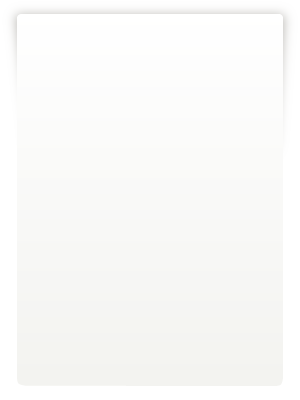
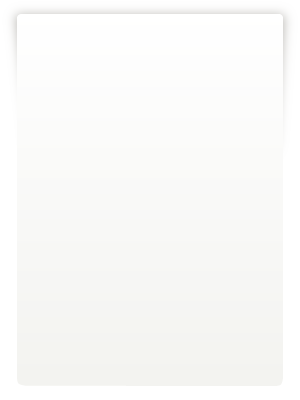
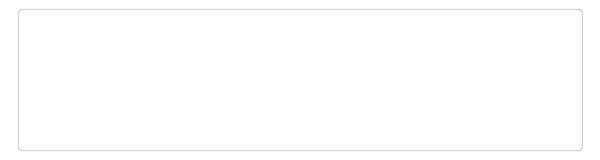
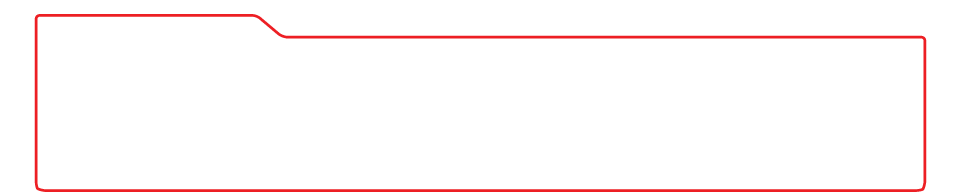
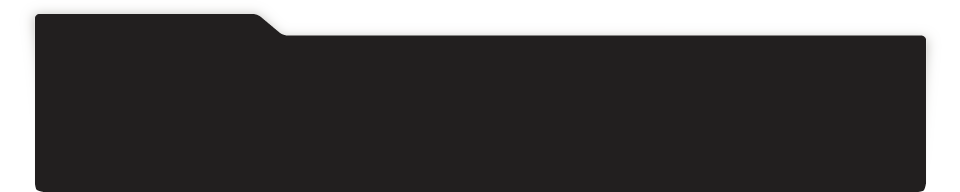
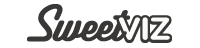
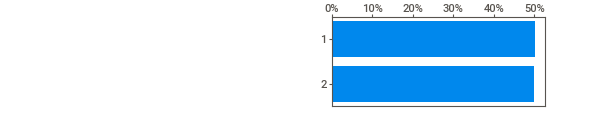
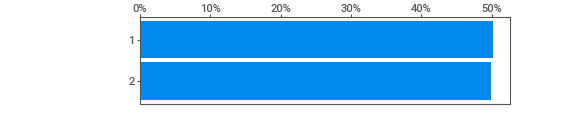
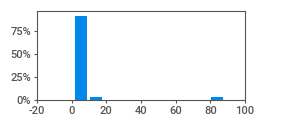
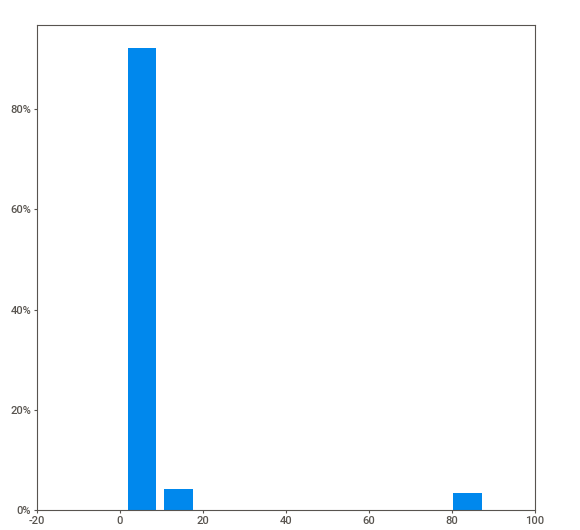
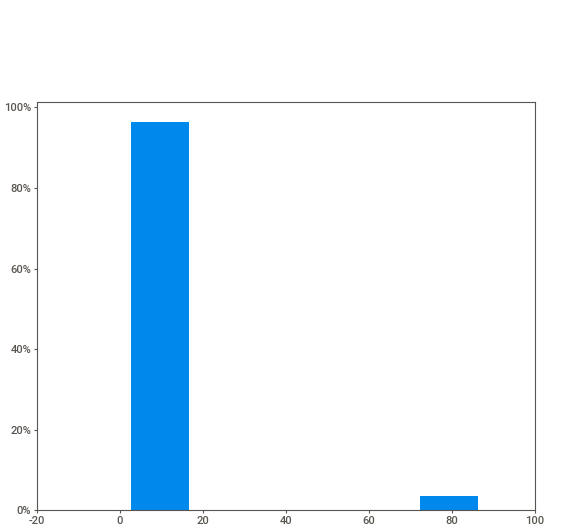
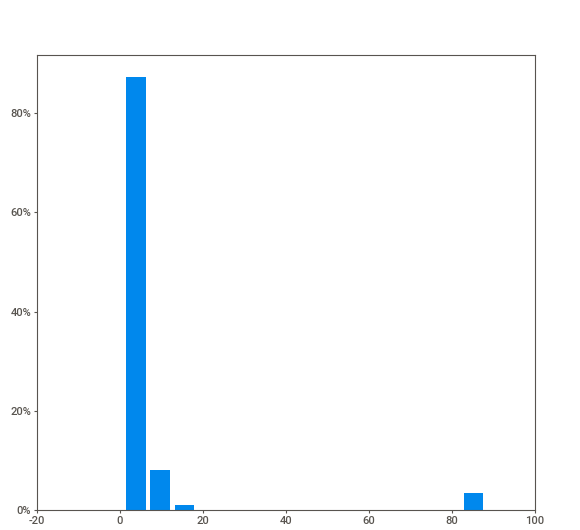
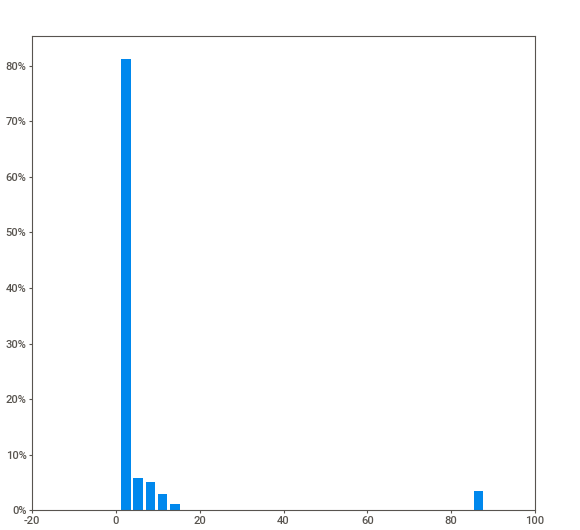
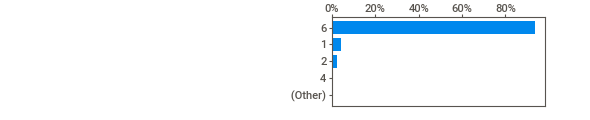
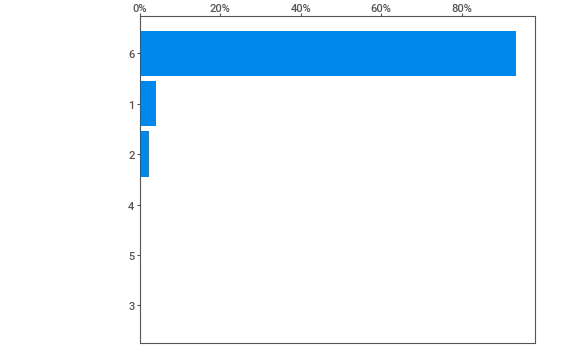
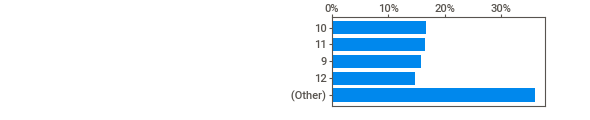
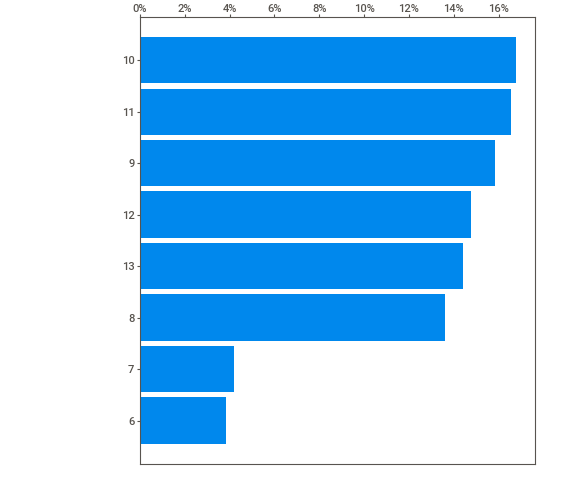
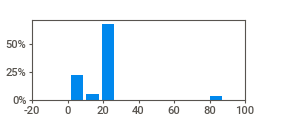
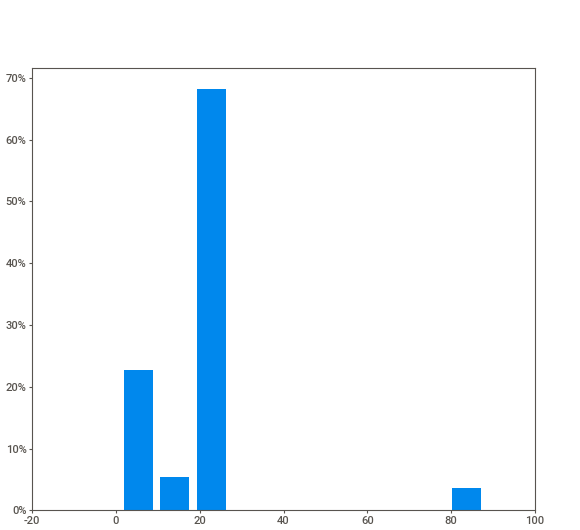
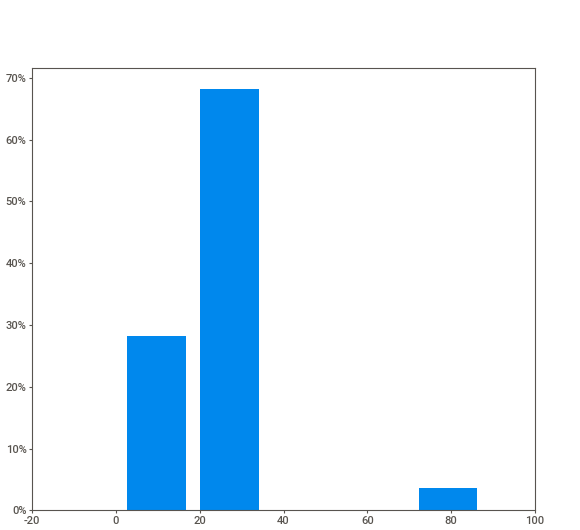
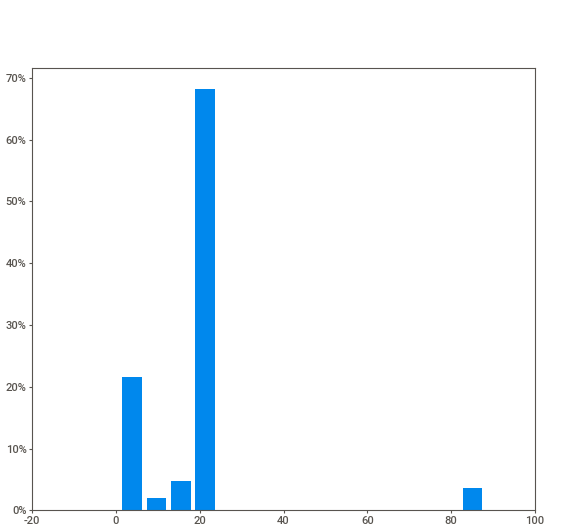
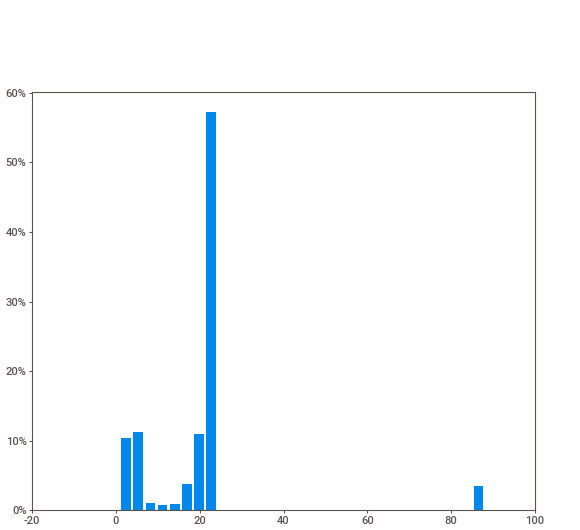
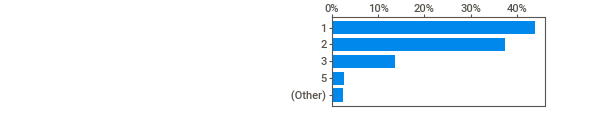
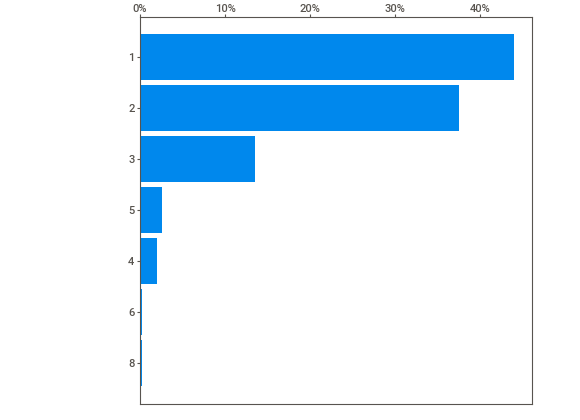
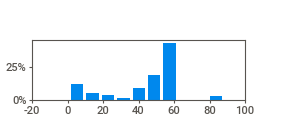
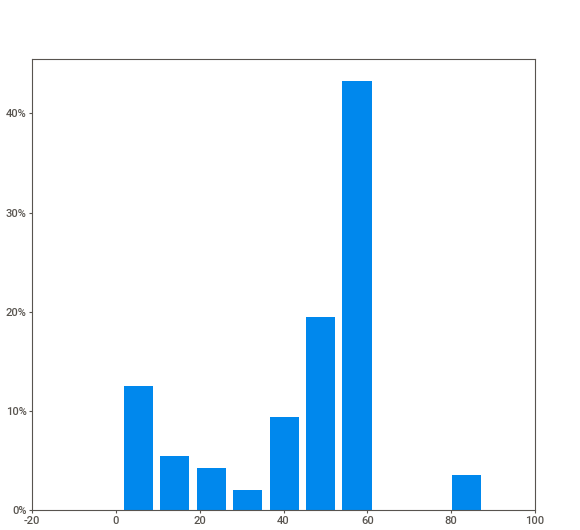
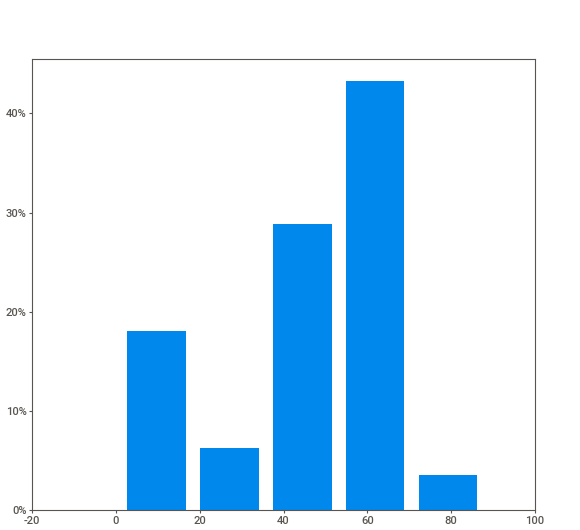
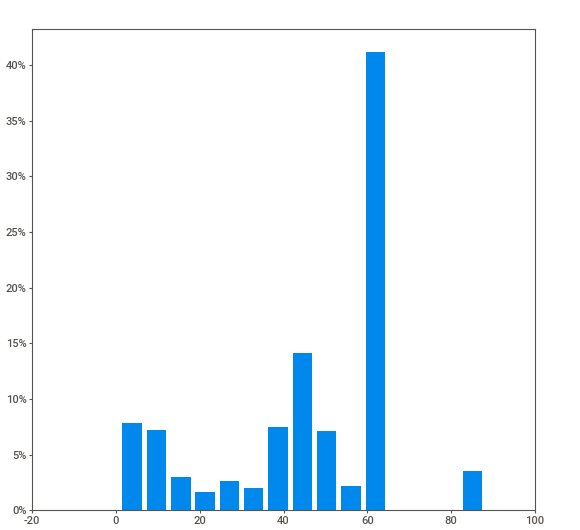
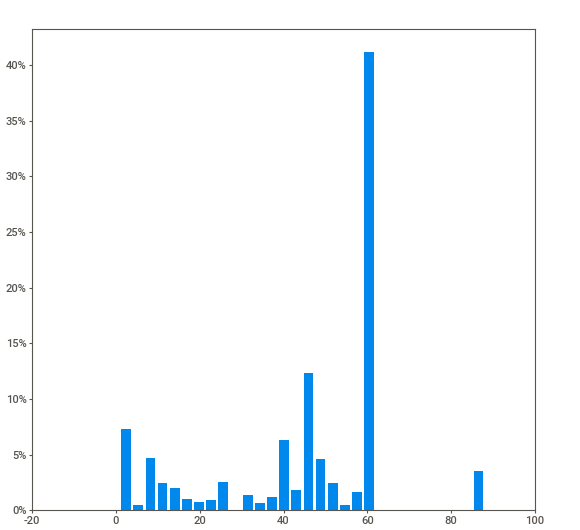
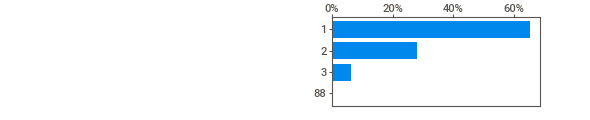
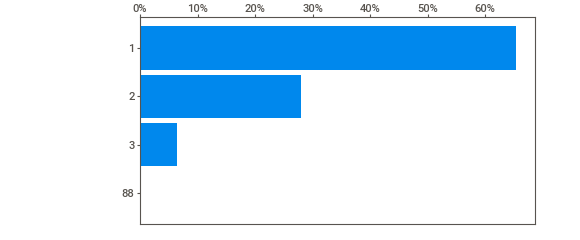
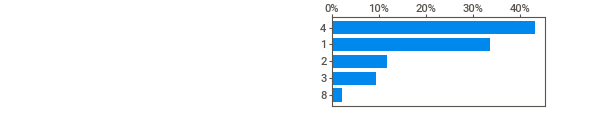
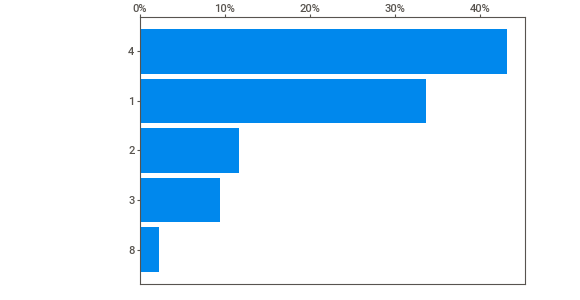
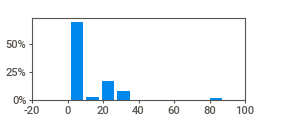
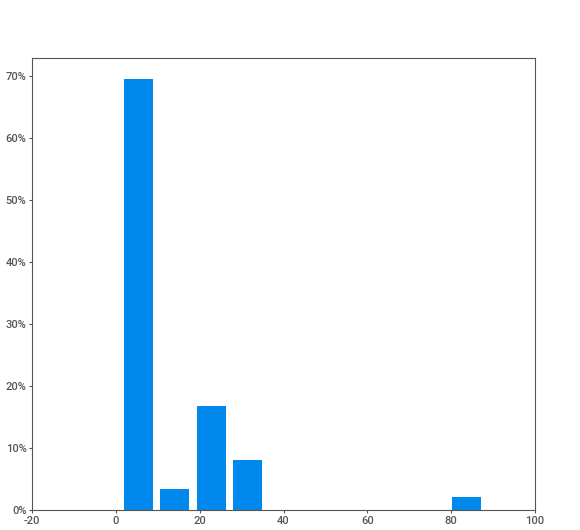
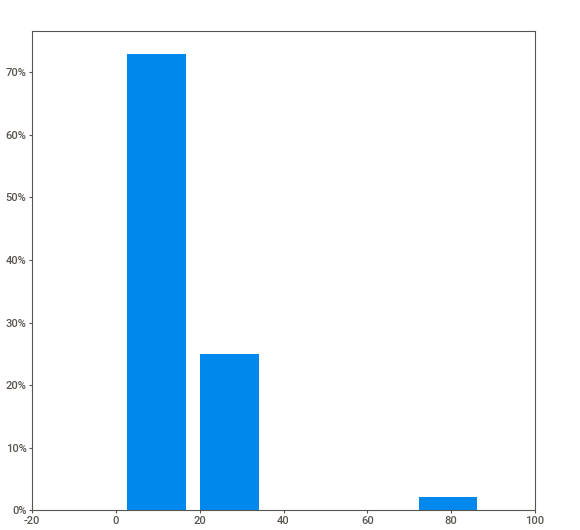
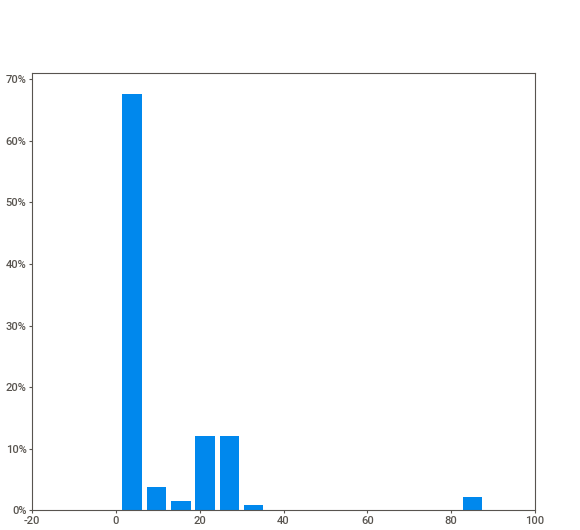
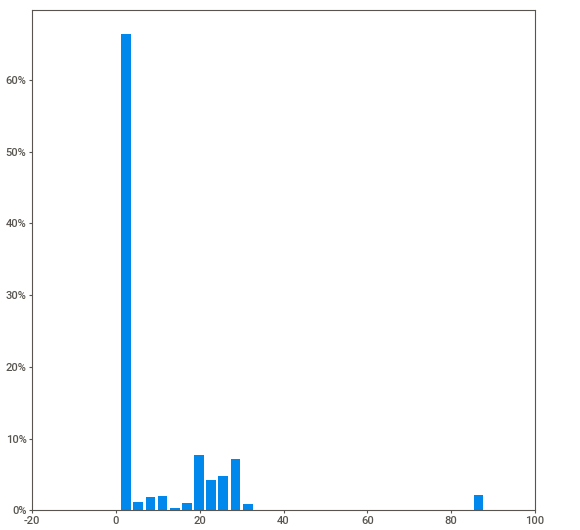
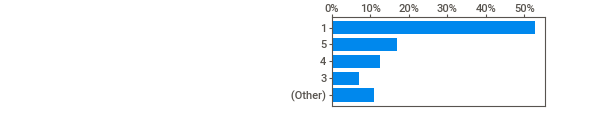
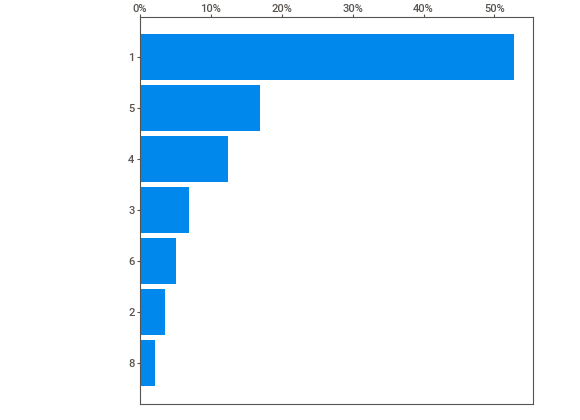
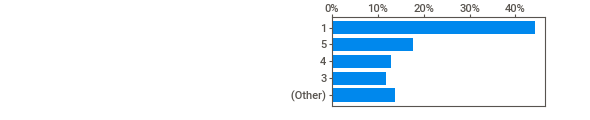
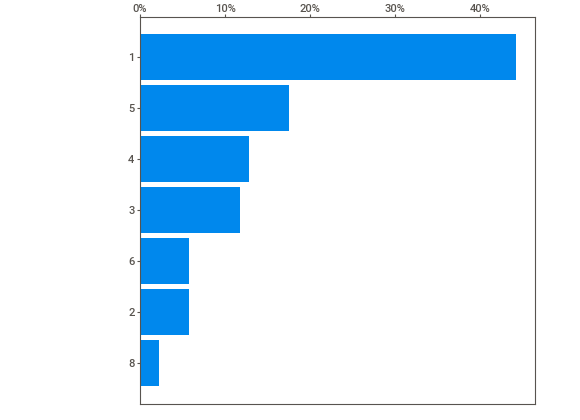
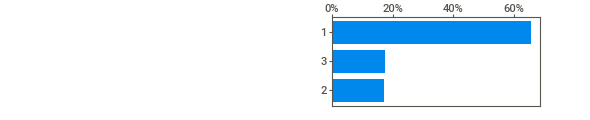
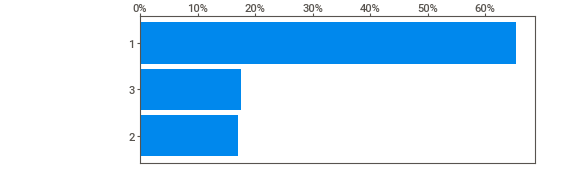
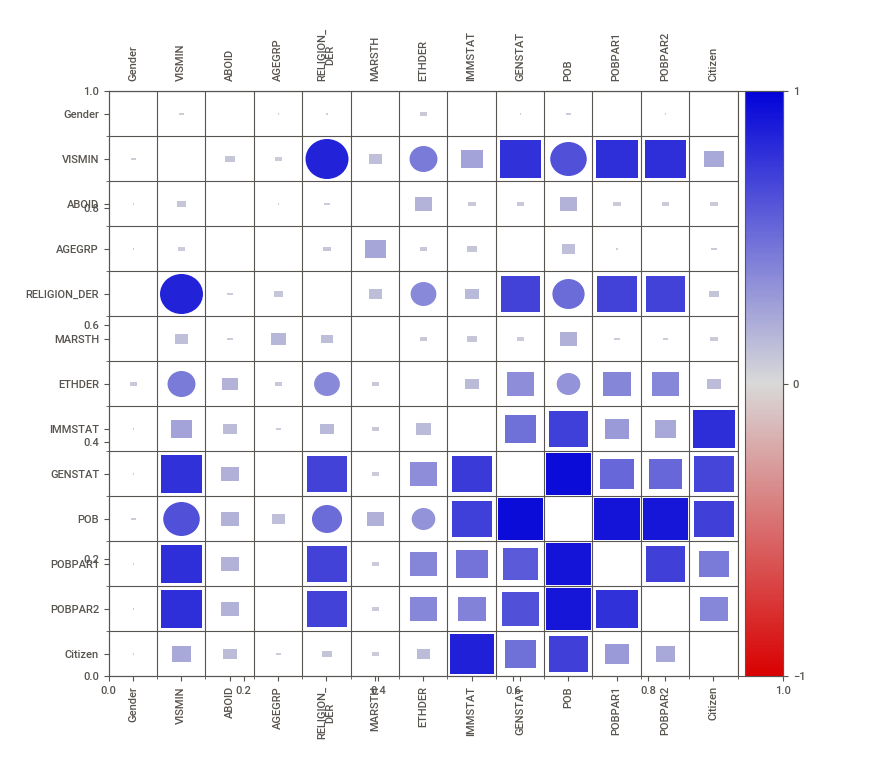
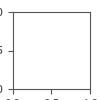

In [6]:
import sweetviz as sv # pip install sweetviz    

fairness_vars = ['Gender', 'VISMIN', 'ABOID', 'AGEGRP', 'RELIGION_DER', 'MARSTH',
                 'ETHDER', 'IMMSTAT', 'GENSTAT', 'POB', 'POBPAR1', 'POBPAR2', 'Citizen']

report = sv.analyze(X[fairness_vars])
report.show_notebook()

# Task B - Explore fairness

## Train test split
We use stratification along the y feature to ensure that the training and the test set have a similar amount of positive and negative examples.

**Do not change the random seed here to ensure that all groups have the same test set**

In [8]:
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, AGEGRP, random_state=42, stratify=y)

## B.1 Train black box model - Random Forest Model

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

### Analyze fit of the model

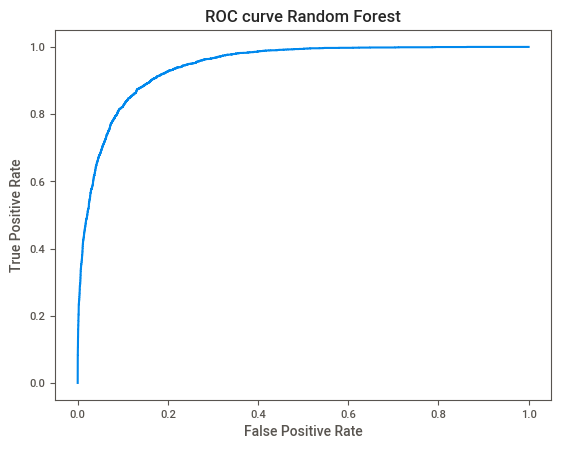

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     11119
           1       0.60      0.90      0.72      3004

    accuracy                           0.85     14123
   macro avg       0.78      0.87      0.81     14123
weighted avg       0.89      0.85      0.86     14123



In [17]:
# predict probabilities of readmission
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:,1]

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Random Forest')
plt.show()

# get classification report and tune threshold in such a way that recall is at least 0.9
threshold = 0.5
print(classification_report(y_test, y_pred > threshold))


In [18]:
print(f" In a group of 1000 individuals approximately {sum(y_pred > threshold) / len(y_pred) * 1000:.0f} have a salary higher than 75k. Amongst these ... \n \
      \t ... {sum((y_test == 1) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are correctly classified; \n \
      \t ... {sum((y_test == 0) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are classified as not having a salary higher than 75k. \n \n \
Additionally, we expect that there are {sum((y_test == 1) & (y_pred < threshold)) / len(y_pred) * 1000:.0f} individuals who have a salary higher than 75k but are not classified as such.")

 In a group of 1000 individuals approximately 320 have a salary higher than 75k. Amongst these ... 
       	 ... 192 are correctly classified; 
       	 ... 129 are classified as not having a salary higher than 75k. 
 
 Additionally, we expect that there are 21 individuals who have a salary higher than 75k but are not classified as such.


## B.2 Train glass box model - logistic regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]

### Analyze fit of the model

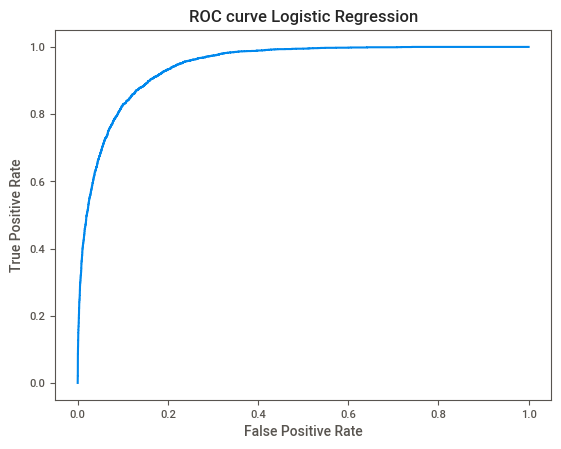

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     11119
           1       0.61      0.90      0.72      3004

    accuracy                           0.85     14123
   macro avg       0.79      0.87      0.81     14123
weighted avg       0.89      0.85      0.86     14123



In [72]:
# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
plt.plot(fpr_lr, tpr_lr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Logistic Regression')
plt.show()

threshold_lr = 0.45
print(classification_report(y_test, y_pred_lr > threshold_lr))

In [21]:
print(f" In a group of 1000 individuals approximately {sum(y_pred_lr > threshold) / len(y_pred_lr) * 1000:.0f} have a salary higher than 75k. Amongst these ... \n \
      \t ... {sum((y_test == 1) & (y_pred_lr > threshold)) / len(y_pred_lr) * 1000:.0f} are correctly classified; \n \
      \t ... {sum((y_test == 0) & (y_pred_lr > threshold)) / len(y_pred_lr) * 1000:.0f} are classified as not having a salary higher than 75k. \n \n \
Additionally, we expect that there are {sum((y_test == 1) & (y_pred_lr < threshold)) / len(y_pred_lr) * 1000:.0f} individuals who have a salary higher than 75k but are not classified as such.")

 In a group of 1000 individuals approximately 300 have a salary higher than 75k. Amongst these ... 
       	 ... 187 are correctly classified; 
       	 ... 113 are classified as not having a salary higher than 75k. 
 
 Additionally, we expect that there are 25 individuals who have a salary higher than 75k but are not classified as such.


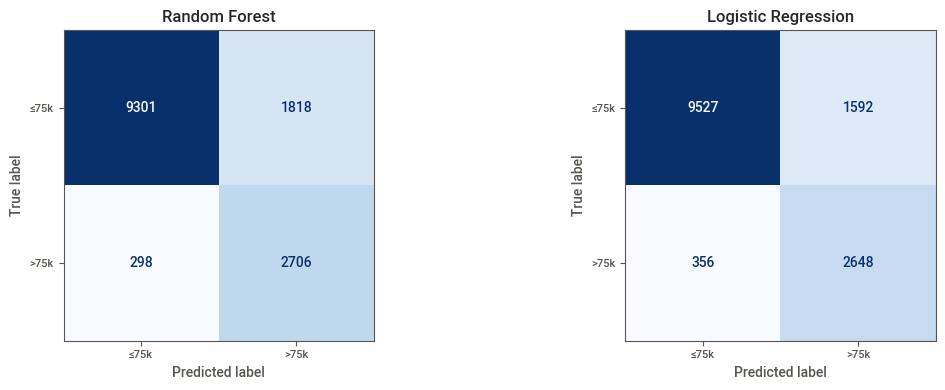

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred_model, title in zip(
  axes,
  [y_pred > threshold, y_pred_lr > threshold_lr],
  ["Random Forest", "Logistic Regression"]
):
  cm = confusion_matrix(y_test, y_pred_model)
  disp = ConfusionMatrixDisplay(cm, display_labels=["≤75k", ">75k"])
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(title)

plt.tight_layout()
plt.show()

## B.3 Fairness criteria: Independence - selections rate parity (demographic parity)
Predictions should be statistically independent of a protected attribute and model should give positive predictions at the same rate across groups.

In [73]:
def independence_parity(y_pred_binary, sensitive):
  results = {}
  for group in sorted(sensitive.unique()):
      mask = sensitive == group
      results[group] = y_pred_binary[mask].mean()
  return pd.Series(results)


def plot_independence_parity(feature_name, y_test, y_pred_rf, y_pred_lr, threshold_rf=0.5, threshold_lr=0.5):
  sensitive = data[feature_name].loc[y_test.index]

  ind_rf = independence_parity(y_pred_rf > threshold_rf, sensitive)
  ind_lr = independence_parity(y_pred_lr > threshold_lr, sensitive)

  pd.DataFrame({
      "Random Forest": ind_rf,
      "Logistic Regression": ind_lr
  }).plot(kind="bar", figsize=(10, 4))
  plt.axhline(y=(y_pred_rf > threshold_rf).mean(), color="steelblue", linestyle="--", label="RF overall")
  plt.axhline(y=(y_pred_lr > threshold_lr).mean(), color="orange", linestyle="--", label="LR overall")
  plt.title(f"Independence (Demographic Parity) by {feature_name}")
  plt.xlabel(f"{feature_name} group")
  plt.ylabel("Positive prediction rate")
  plt.legend()
  plt.tight_layout()
  plt.show()

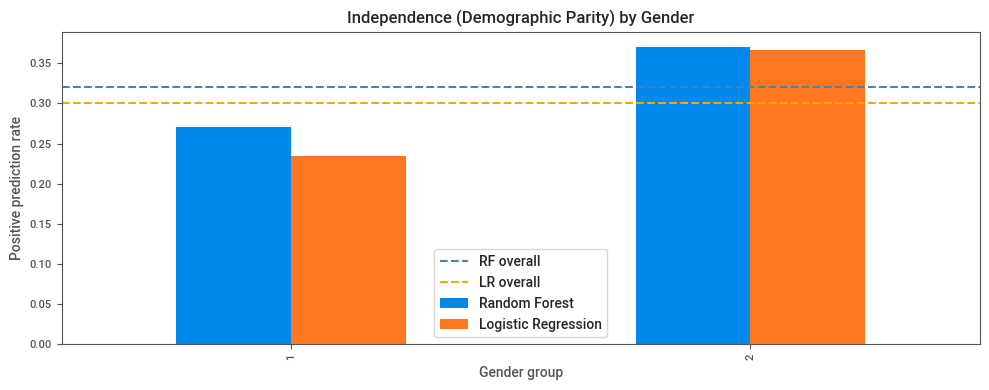

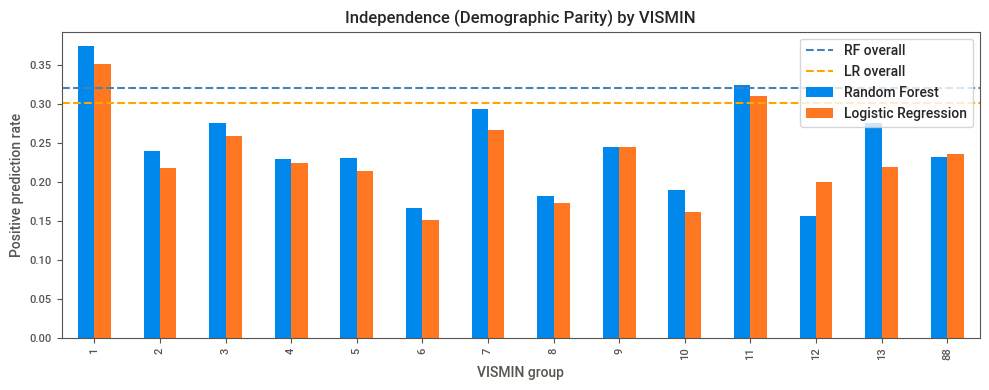

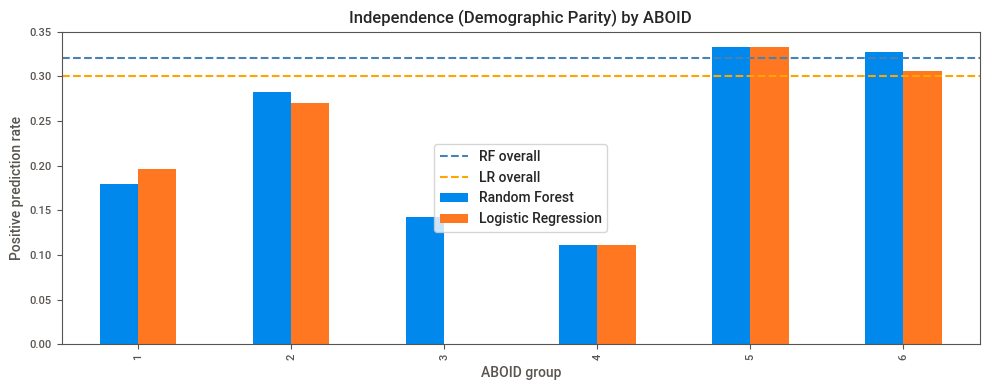

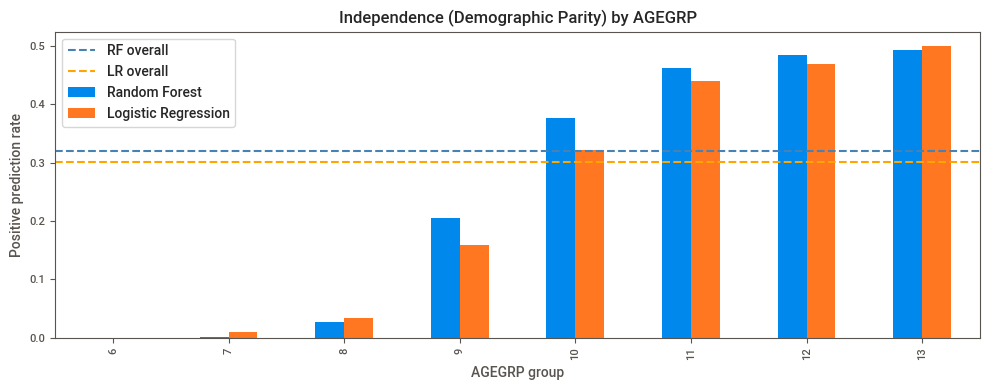

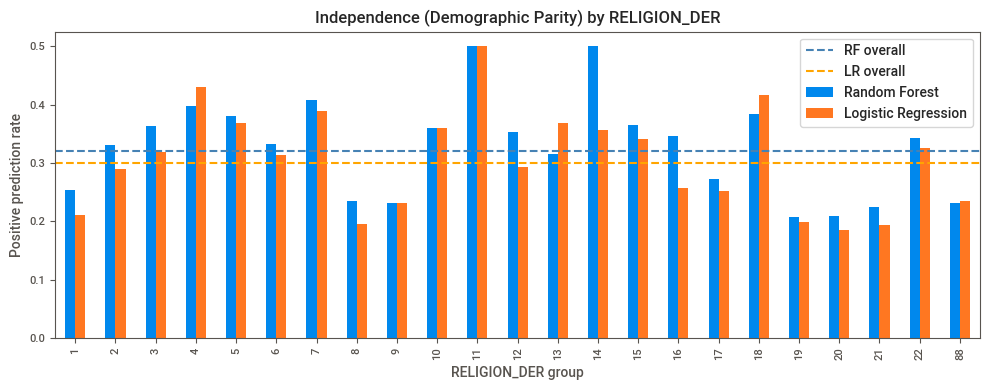

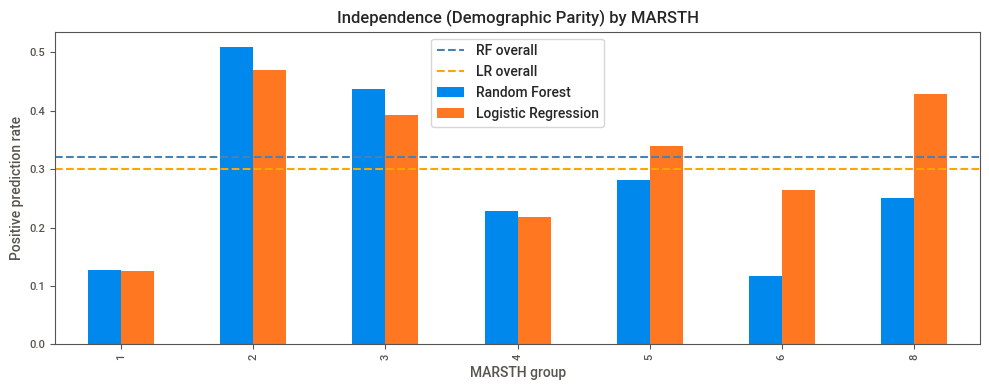

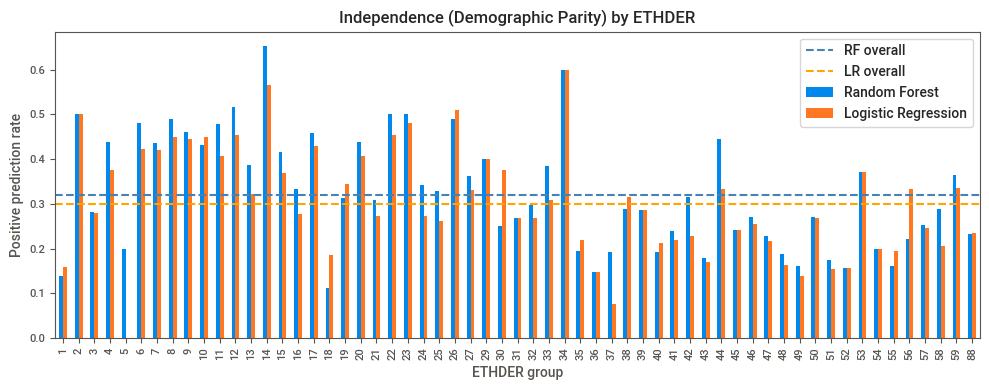

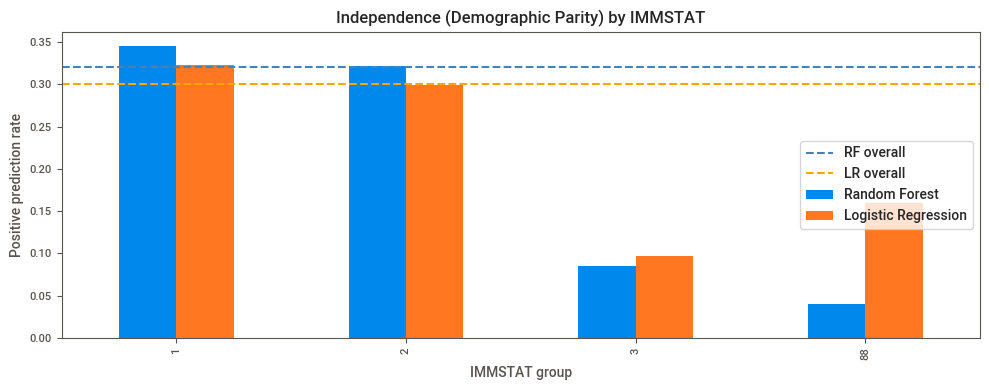

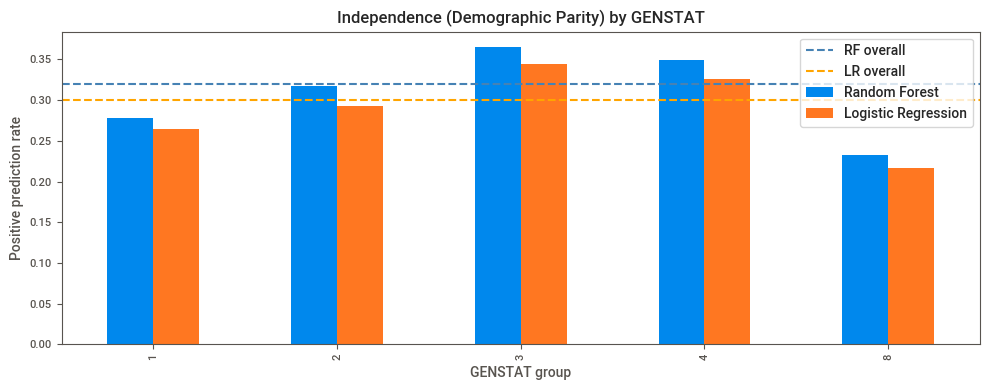

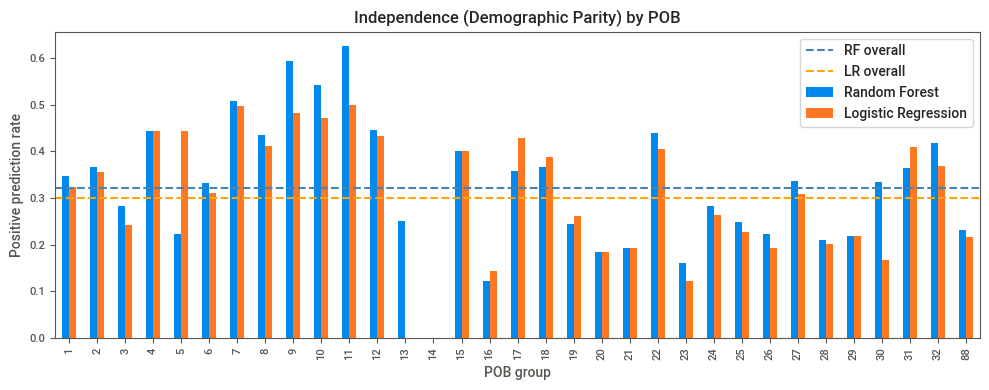

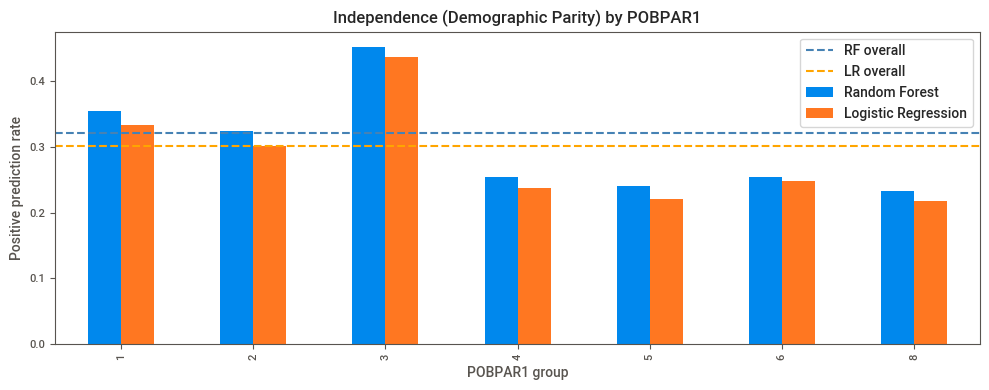

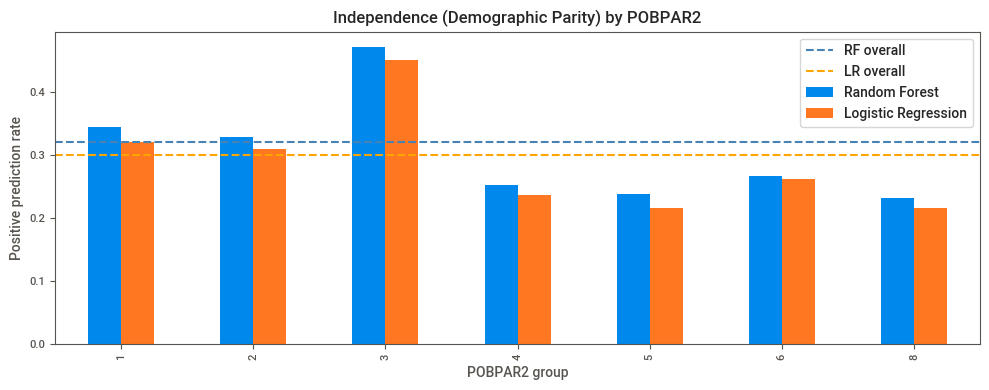

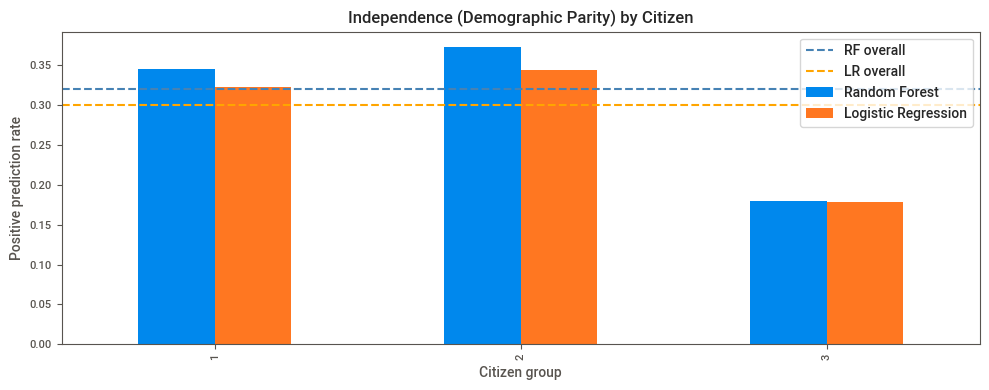

In [74]:
for fairness_var in fairness_vars:
    plot_independence_parity(fairness_var, y_test, y_pred, y_pred_lr)

## B.4 Fairness criteria: Separation - error rate parity
Error rate parity (also called separation) is a fairness criterion that focuses on equalizing error rates across groups, conditional on the true outcome.

The model should be equally accurate (or equally wrong) across groups.

In [55]:
from sklearn.metrics import confusion_matrix

def separation_parity(y_true, y_pred_binary, sensitive):
  results = {}
  for group in sorted(sensitive.unique()):
      mask = sensitive == group
      tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred_binary[mask], labels=[0, 1]).ravel()
      results[group] = {
          "TPR": tp / (tp + fn) if (tp + fn) > 0 else 0,
          "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0,
      }
  return pd.DataFrame(results).T


def plot_separation_parity(feature_name, y_test, y_pred_rf, y_pred_lr, threshold_rf=0.5, threshold_lr=0.5):
  sensitive = data[feature_name].loc[y_test.index]

  sep_rf = separation_parity(y_test, y_pred_rf > threshold_rf, sensitive)
  sep_lr = separation_parity(y_test, y_pred_lr > threshold_lr, sensitive)

  fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

  for ax, metric in zip(axes, ["TPR", "FPR"]):
      pd.DataFrame({
          "Random Forest": sep_rf[metric],
          "Logistic Regression": sep_lr[metric]
      }).plot(kind="bar", ax=ax)
      ax.set_title(f"{metric} by {feature_name}")
      ax.set_xlabel(f"{feature_name} group")
      ax.set_ylabel(metric)
      ax.legend()

  plt.suptitle(f"Separation by {feature_name}")
  plt.tight_layout()
  plt.show()

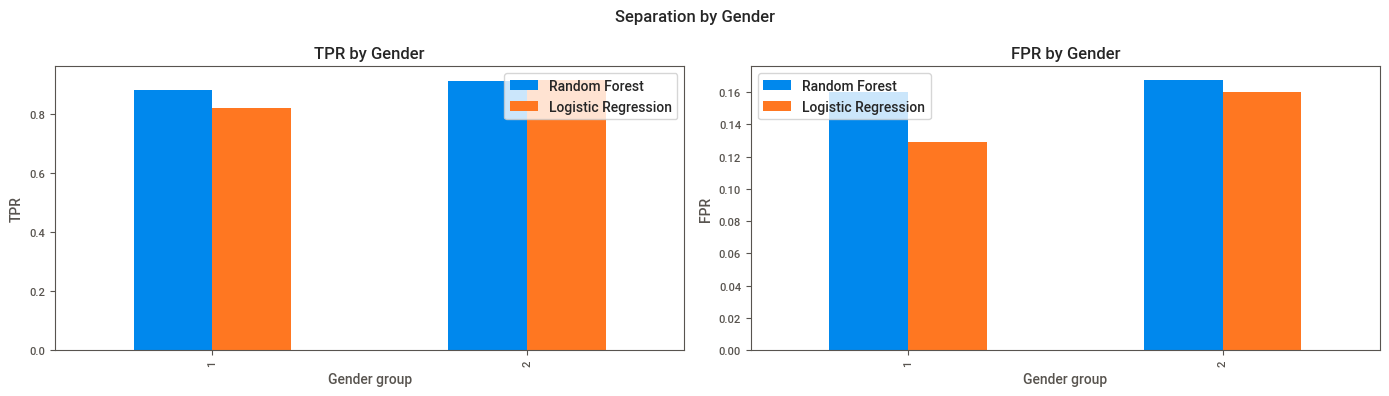

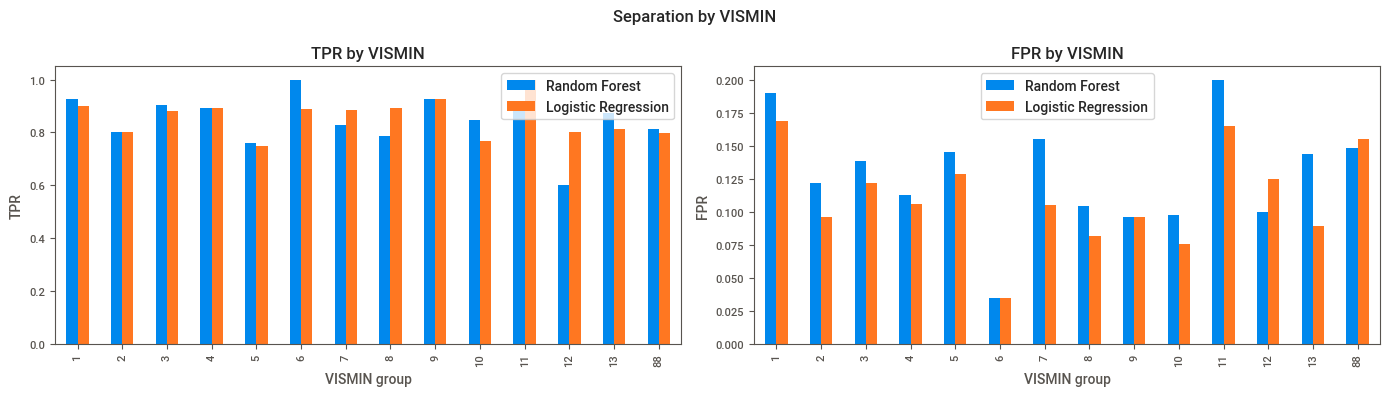

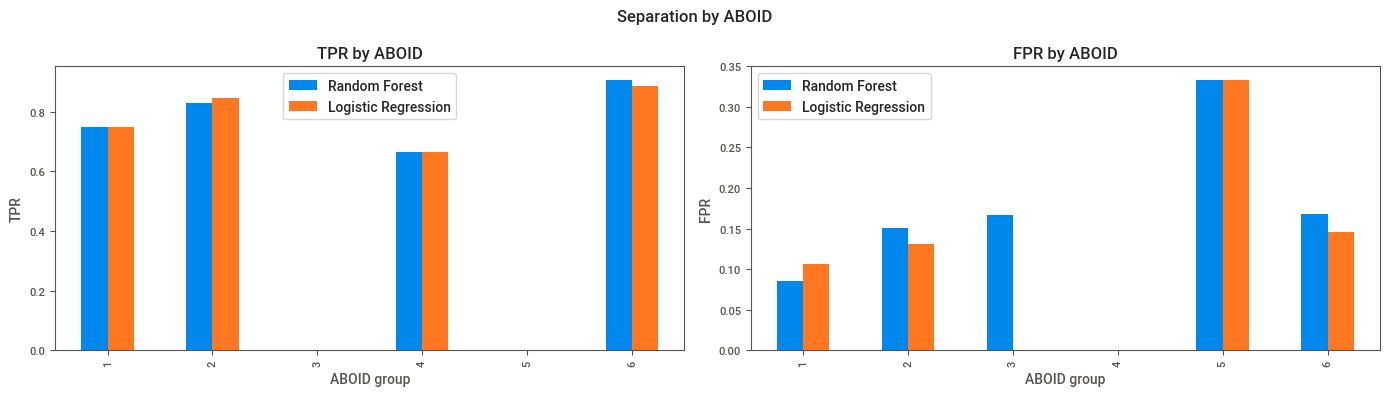

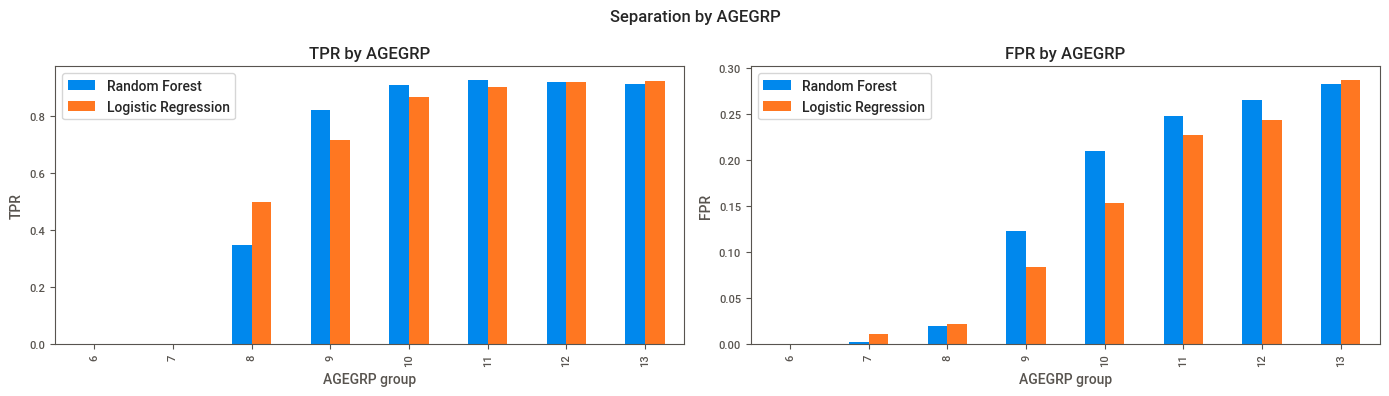

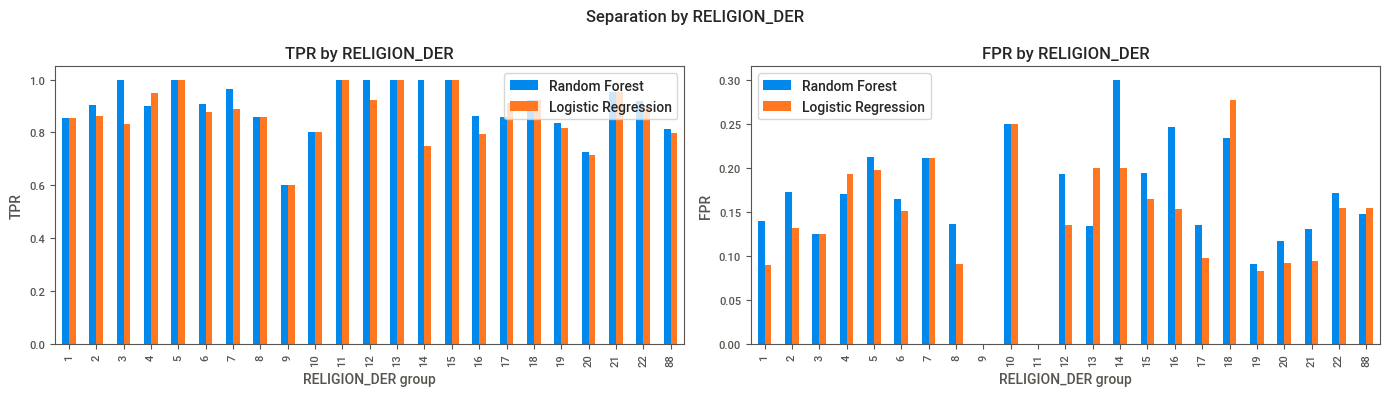

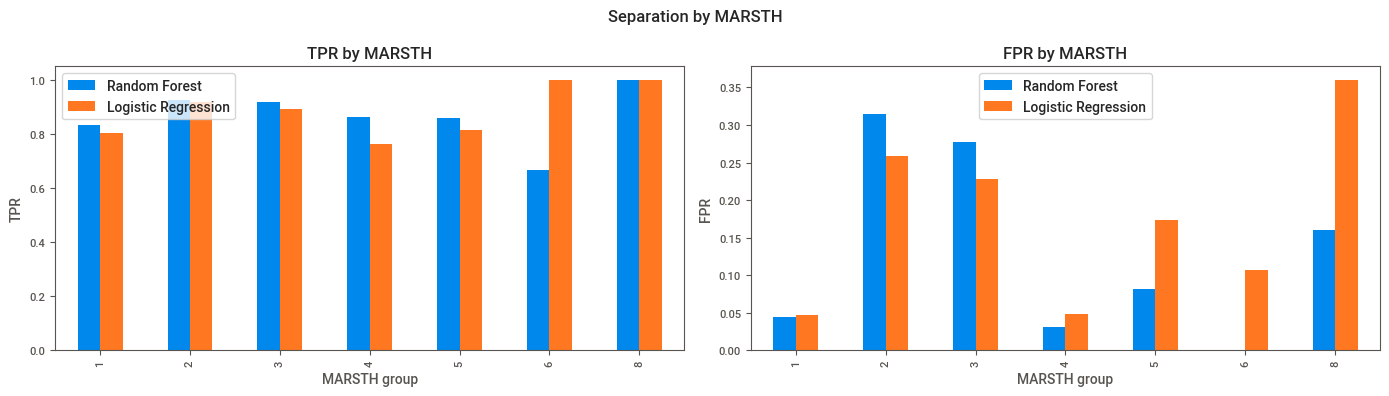

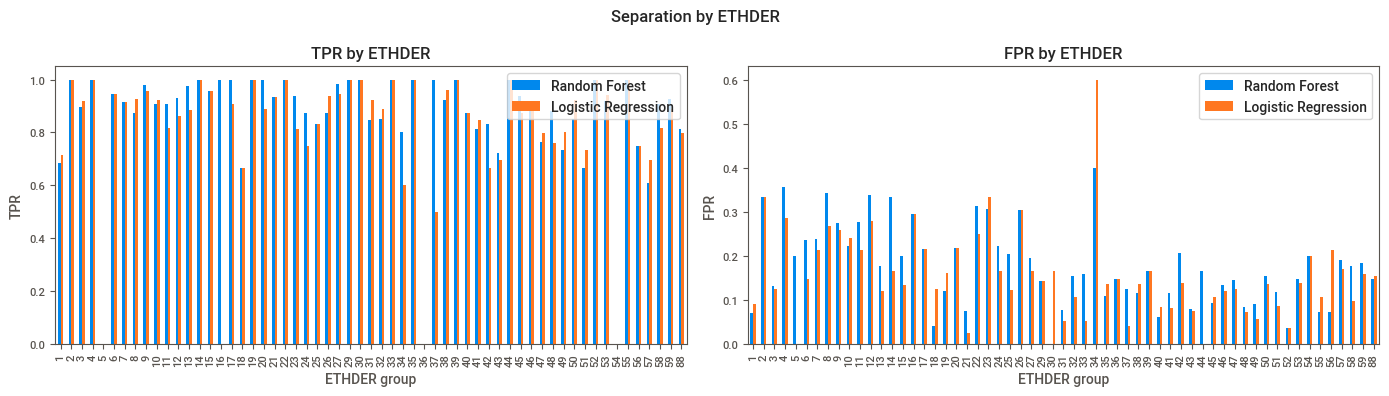

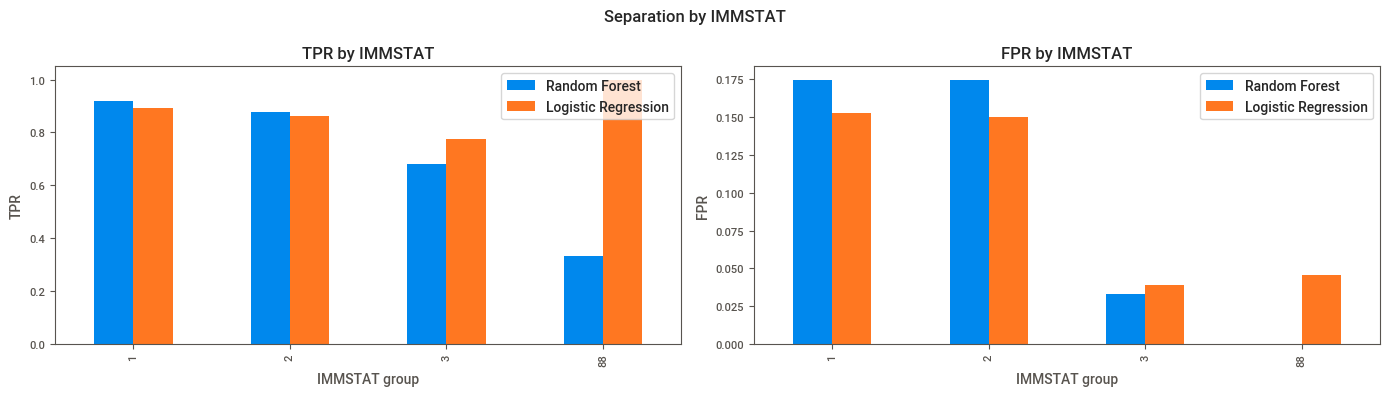

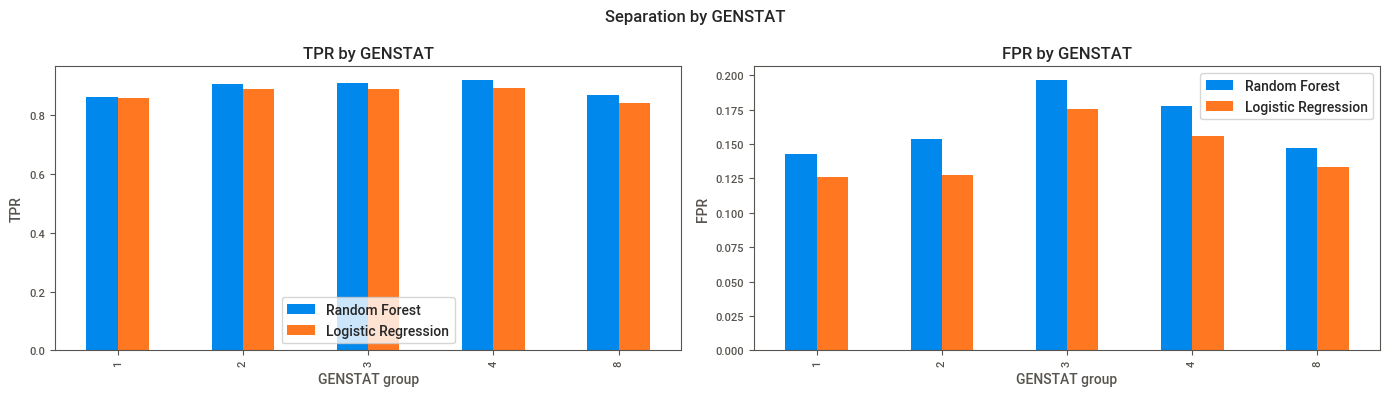

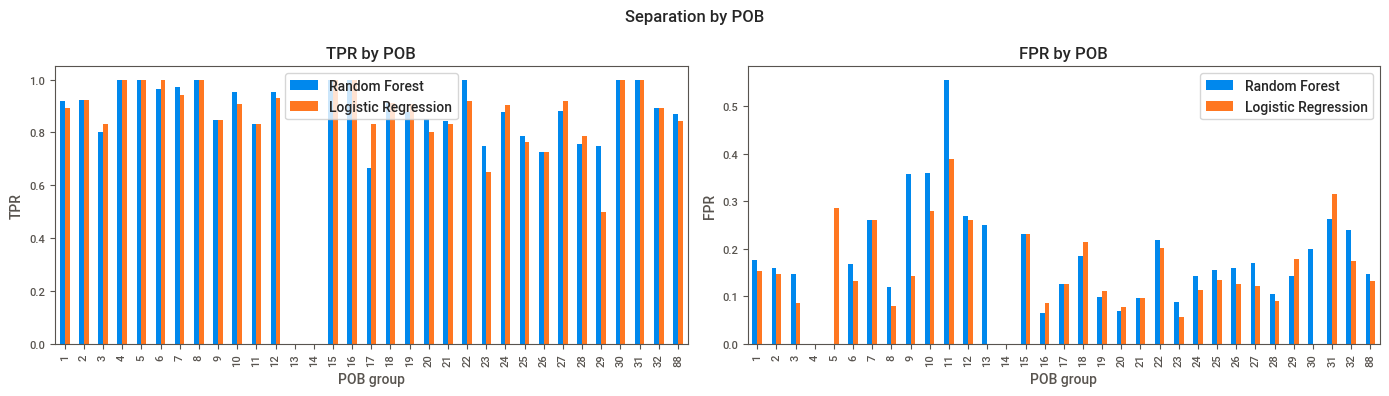

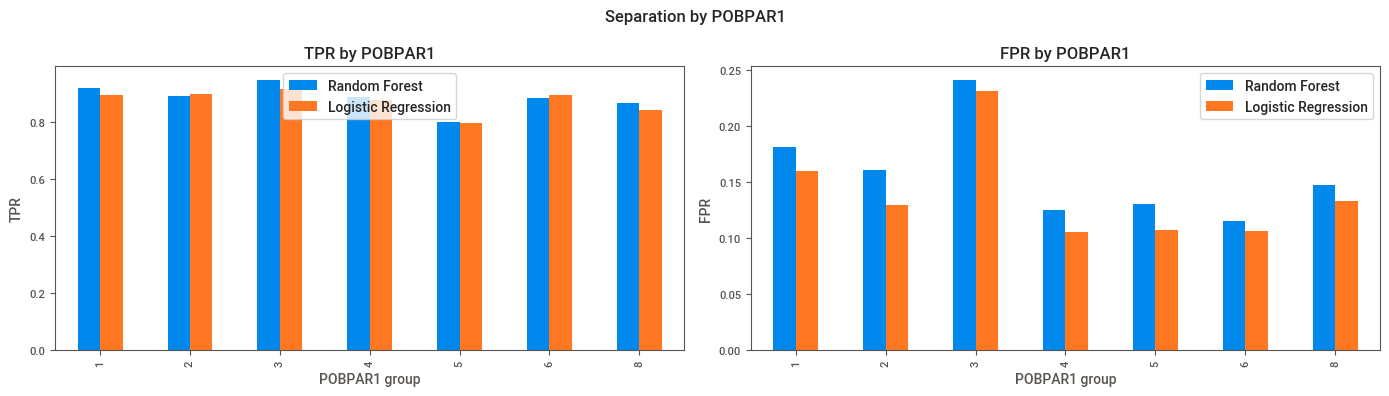

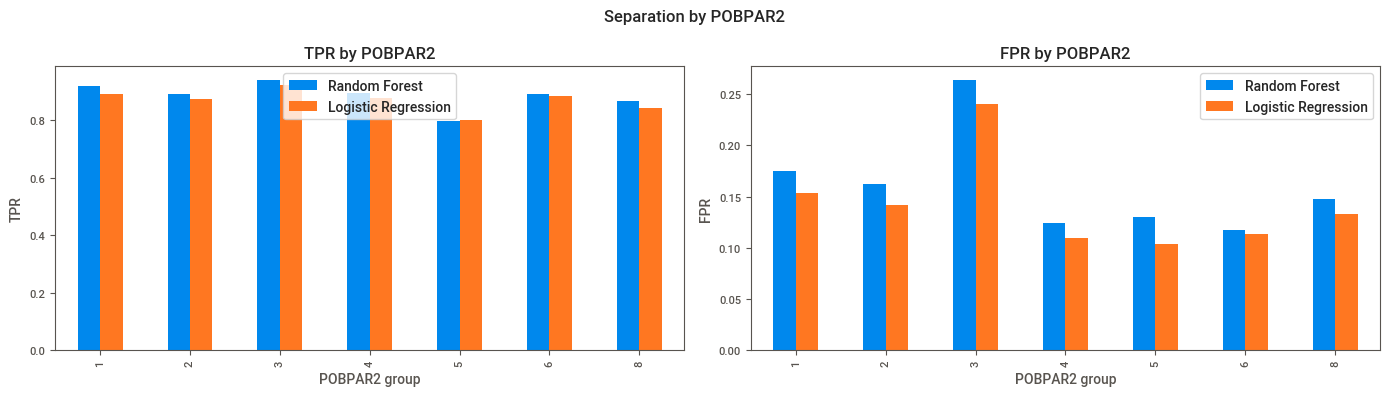

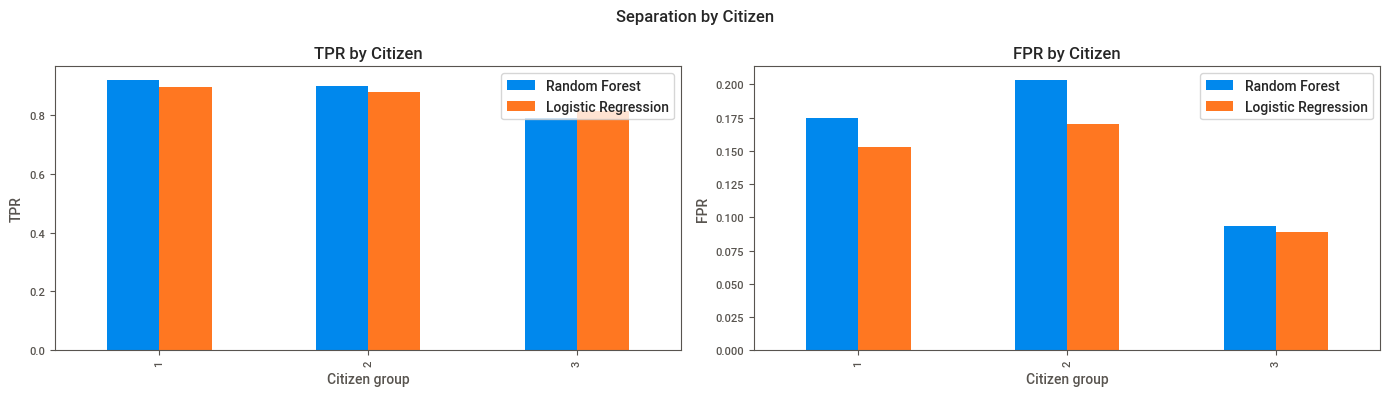

In [56]:
for fairness_var in fairness_vars:
    plot_separation_parity(fairness_var, y_test, y_pred, y_pred_lr)

## B.5 Fairness criteria: Sufficiency
In binary predictions sufficiency reduces to precision parity across groups.

In our case precision = of everyone the model predicted as >75k, what fraction actually earns >75k

In [65]:
def sufficiency_parity(y_true, y_pred_binary, sensitive):
  results = {}
  for group in sorted(sensitive.unique()):
      mask = sensitive == group
      tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred_binary[mask], labels=[0, 1]).ravel()
      results[group] = {
          "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
      }
  return pd.DataFrame(results).T


def plot_sufficiency_parity(feature_name, y_test, y_pred_rf, y_pred_lr, threshold_rf=0.5, threshold_lr=0.5):
  sensitive = data[feature_name].loc[y_test.index]

  suf_rf = sufficiency_parity(y_test, y_pred_rf > threshold_rf, sensitive)
  suf_lr = sufficiency_parity(y_test, y_pred_lr > threshold_lr, sensitive)

  pd.DataFrame({
      "Random Forest": suf_rf["Precision"],
      "Logistic Regression": suf_lr["Precision"]
  }).plot(kind="bar", figsize=(10, 4))
  plt.title(f"Sufficiency (Precision) by {feature_name}")
  plt.xlabel(f"{feature_name} group")
  plt.ylabel("Precision")
  plt.legend()
  plt.tight_layout()
  plt.show()

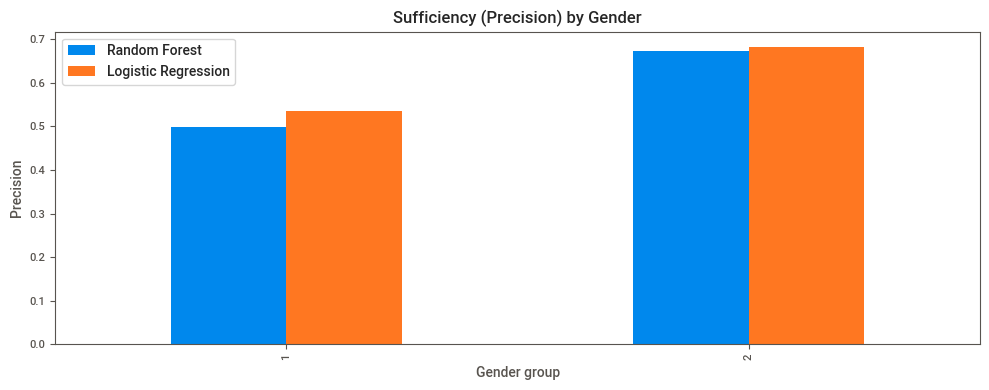

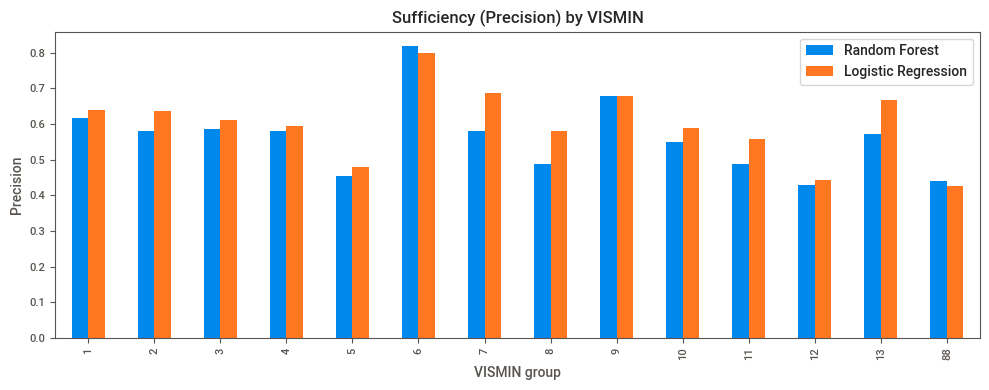

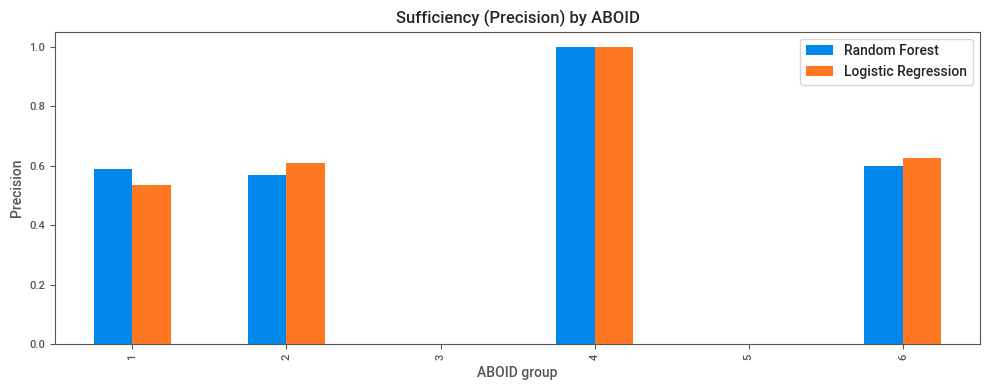

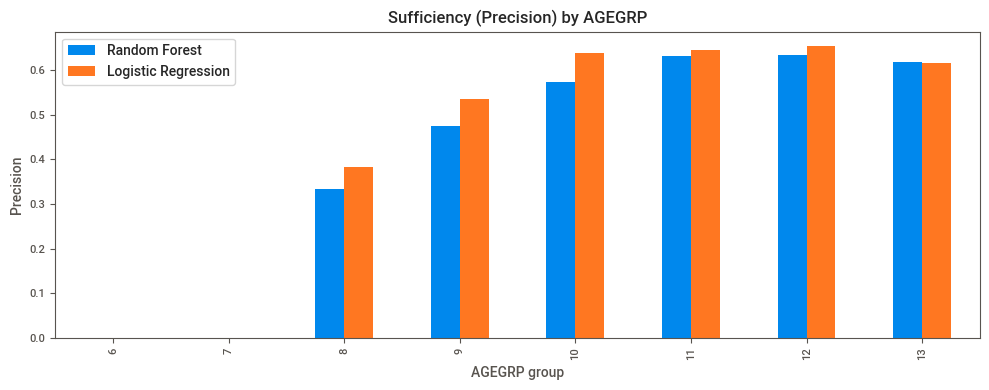

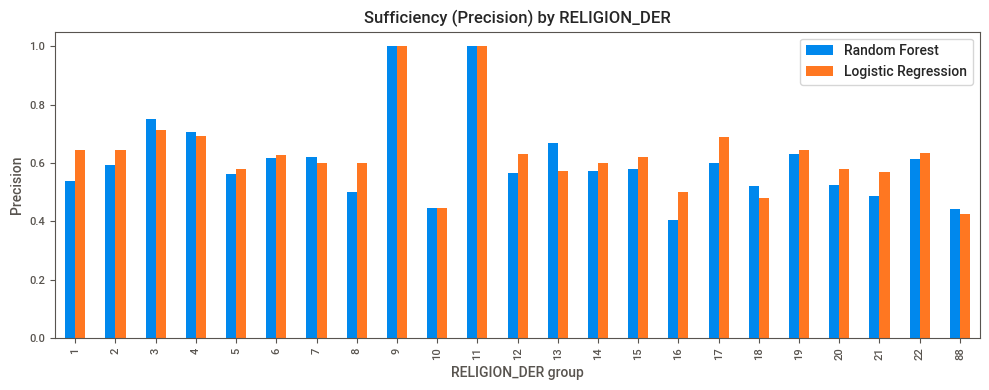

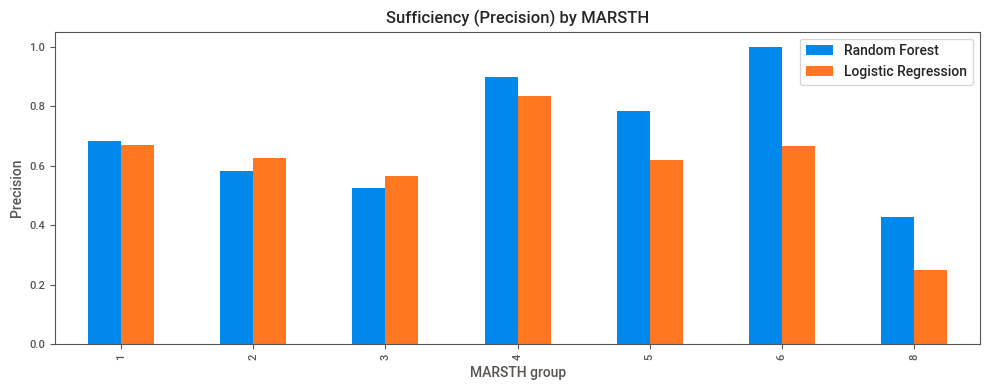

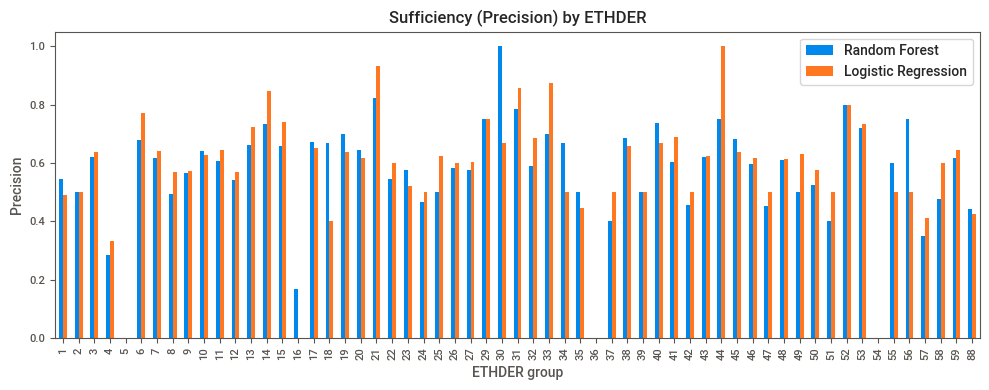

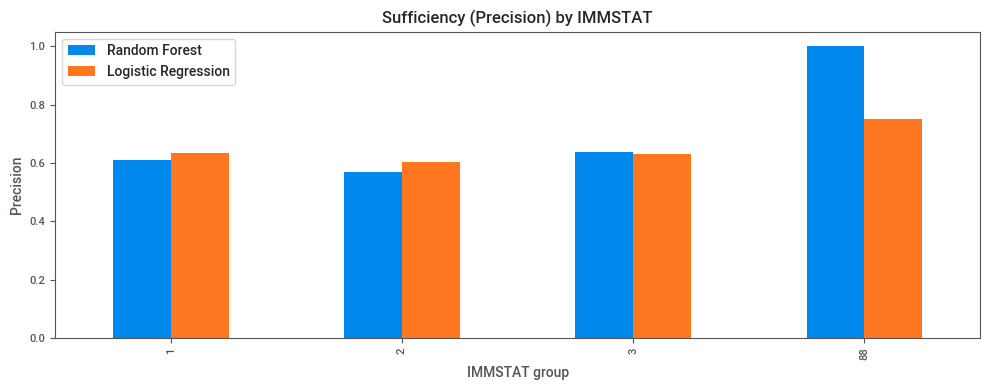

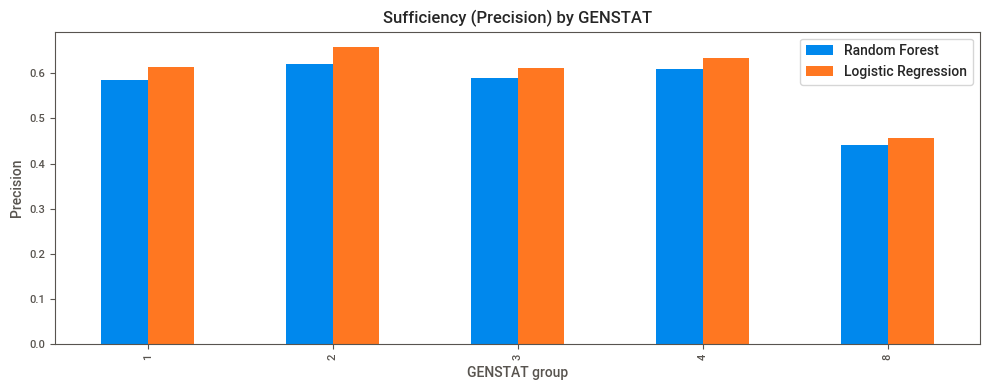

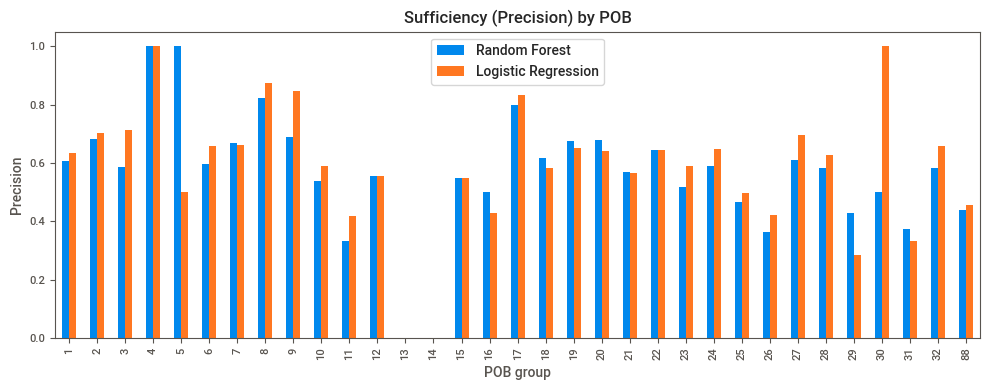

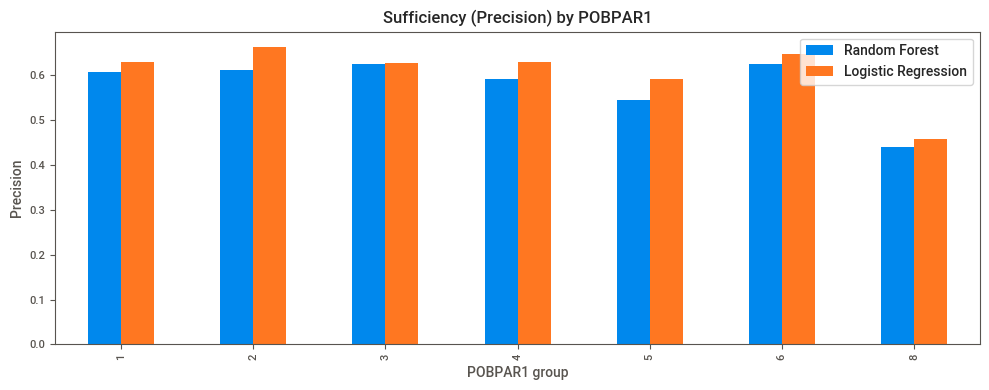

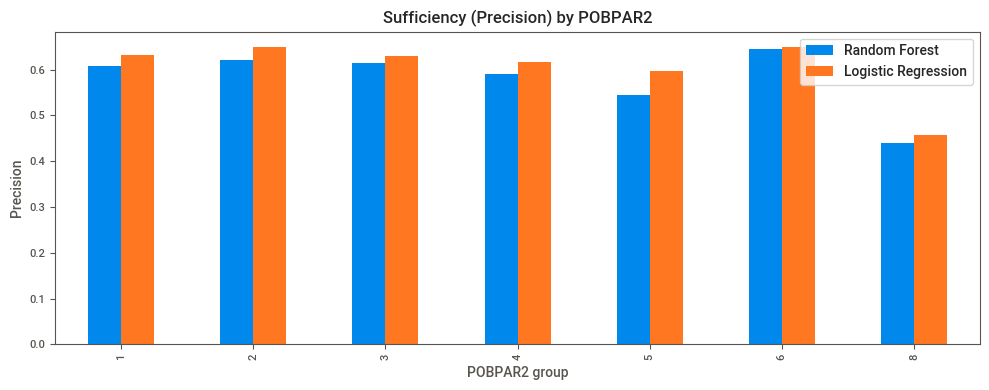

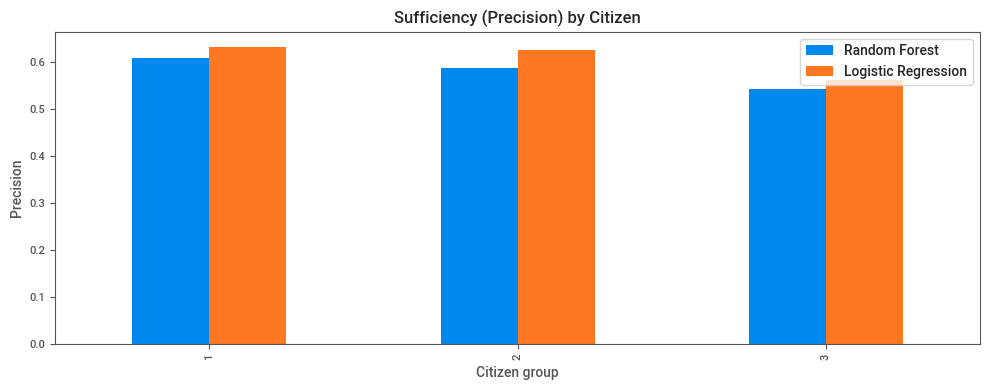

In [66]:
for fairness_var in fairness_vars:
    plot_sufficiency_parity(fairness_var, y_test, y_pred, y_pred_lr)